In [1]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *
import matplotlib.pyplot as plt

## TOTAL3 (Altcoin Market Cap (Excluding ETH & Stablecoins, BTC)
- O valor de mercado total de todas as criptomoedas, subtraindo Bitcoin, Ethereum e Stablecoins. Muitas vezes representado pelo ticker TOTAL3 no TradingView.

- Representa o "Apetite por Risco Extremo". É o índice das Shitcoins, Memecoins e projetos menores ("Alts").

- Fonte: https://br.tradingview.com/symbols/TOTAL3/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
A Rotação de Capital e Dispersão Especulativa. O comportamento do investidor de retalho caracterizava-se pela busca de "o próximo Bitcoin". Hipotetiza-se que o crescimento explosivo do TOTAL3 (Altseason) tinha uma correlação complexa e frequentemente defasada com o preço do Bitcoin. Em momentos de euforia extrema, o capital rotacionava para fora do Bitcoin para alimentar ICOs, criando uma pressão de venda relativa ou estagnação no preço do líder de mercado em prol dos ativos de cauda longa.

## Hipótese 2: Era Institucional (Pós-2020)
O Beta do Ecossistema (Correlação Sistêmica). Para investidores institucionais, o TOTAL3 funciona como um termômetro de apetite ao risco para a classe de ativos como um todo. Hipotetiza-se uma forte correlação positiva simultânea. Neste regime, não há "dissociação": se o TOTAL3 cai (liquidação de Altcoins), isso sinaliza aversão ao risco sistêmico (Crypto Winter), arrastando o preço do Bitcoin junto. O Bitcoin atua como o índice "Beta 1", e o TOTAL3 como uma versão alavancada da mesma tendência.

### TRATAMENTO
- O desvio padrão dos retornos (std) é de 4.9% ao dia. O máximo (max) é 48.9% em um único dia.
- Modelos como XGBoost adoram essa volatilidade, mas ela pode gerar ruído. O Log-Retorno é essencial para "domar" essa escala que foi de 600 milhões (2017) para 900 bilhões (2021).

In [2]:
df_total3 = (pd.read_csv(rf"raw/201501_mkcap_total3.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], unit='s', utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'total3_close'}) 

                        [['Data_UTC', 'total3_close']] 
 
)
df_total3

df_total3_log_Ret =(
    df_periodo
        .merge(df_total3, how='left', on='Data_UTC')
        .assign(total3_close = lambda df: df['total3_close'].ffill())
        .assign(total3_log_ret = lambda df: np.log(df['total3_close']) - np.log(df['total3_close'].shift(1)))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))


        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','total3_close','total3_log_ret']]

)
df_total3_log_Ret

# print_dataframe_info(df_total3_log_Ret, "Total3 Market Cap")

,Data_UTC,total3_close,total3_log_ret
4,2017-01-04,8.000004e+08,0.079352
5,2017-01-05,7.574391e+08,-0.054669
6,2017-01-06,7.014694e+08,-0.076766
7,2017-01-07,6.906900e+08,-0.015486
8,2017-01-08,6.991268e+08,0.012141
...,...,...,...
3131,2025-07-28,7.721518e+11,-0.039505
3132,2025-07-29,7.661266e+11,-0.007834
3133,2025-07-30,7.543308e+11,-0.015516
3134,2025-07-31,7.336012e+11,-0.027866


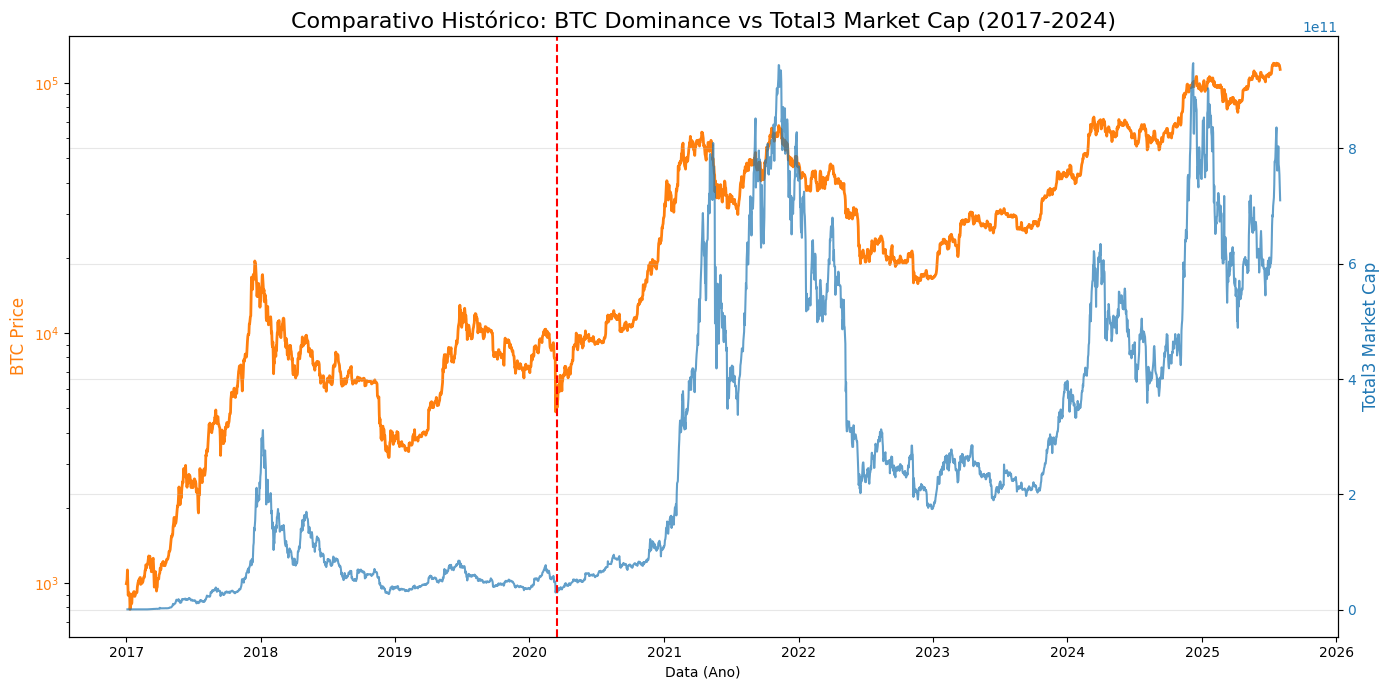

In [3]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('Total3 Market Cap', color=color, fontsize=12)
ax2.plot(df_total3_log_Ret['Data_UTC'], df_total3_log_Ret['total3_close'], color=color, label='Total3 Market Cap', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs Total3 Market Cap (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## Stablecoin Supply Ratio (SSR)
- A razão entre o Market Cap do Bitcoin e o Market Cap de todas as Stablecoins.
- Mede o "Poder de Compra Latente".
    - SSR Baixo: As stablecoins têm muito poder de compra em relação ao tamanho do BTC (Bullish).
    - SSR Alto: O Bitcoin está "caro" em relação à liquidez disponível (Bearish).

- Fonte: https://www.tradingview.com/script/4yIVcZS3-Stablecoin-Supply-Ratio-Oscillator/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Baixa Relevância (Dominância Fiat). A infraestrutura de mercado dependia primordialmente de pares fiduciários (BTC/USD, BTC/KRW). O volume de Tether (USDT) era incipiente comparado ao volume spot direto. Hipotetiza-se que o SSR tinha baixo poder explicativo sobre o preço do Bitcoin, pois a liquidez não estava represada em stablecoins, mas sim em depósitos bancários tradicionais fora da blockchain.

## Hipótese 2: Era Institucional (Pós-2020)
O Indicador de "Pólvora Seca" (Dry Powder). Com a dolarização da economia cripto via USDT e USDC, o SSR tornou-se o principal oscilador de liquidez latente. Hipotetiza-se uma causalidade negativa forte entre o SSR e o preço futuro.

SSR Cai (Pólvora Alta): A oferta de stablecoins é grande em relação ao valor do Bitcoin. Isso indica alto poder de compra represado nas exchanges, pronto para ser alocado, impulsionando o preço.

SSR Sobe (Pólvora Baixa): O preço do Bitcoin subiu muito frente à liquidez disponível, sinalizando exaustão da demanda e potencial topo local.


### TRATAMENTO
- Primeira Diferença (após Forward Fill)
- Justificativa: Como um oscilador de liquidez, a diferença diária captura a injeção (ou retirada) líquida de poder de compra. Variações negativas indicam aumento relativo da "munição" dos compradores (bullish), enquanto variações positivas indicam esticamento da valorização (bearish).

In [5]:
df_ssr = (pd.read_csv(rf"raw/201404_ssr.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        [['Data_UTC', 'SSR']] 
 
)
df_ssr

df_ssr_diff =(
    df_periodo
        .merge(df_ssr, how='left', on='Data_UTC')
        .assign(ssr = lambda df: df['SSR'].ffill())
        .assign(ssr_diff = lambda df: df['ssr'].diff())
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))

        .query("Data_UTC > '2017-01-03'")
        [['Data_UTC','ssr','ssr_diff']]
)
df_ssr_diff

# print_dataframe_info(df_ssr_diff, "SSR Diff") 

,Data_UTC,ssr,ssr_diff
4,2017-01-04,1.171296,0.117991
5,2017-01-05,1.030821,-0.140475
6,2017-01-06,0.917995,-0.112826
7,2017-01-07,0.933154,0.015159
8,2017-01-08,0.627318,-0.305836
...,...,...,...
3131,2025-07-28,1.094782,-0.010777
3132,2025-07-29,1.093483,-0.001299
3133,2025-07-30,1.090745,-0.002737
3134,2025-07-31,1.071763,-0.018982


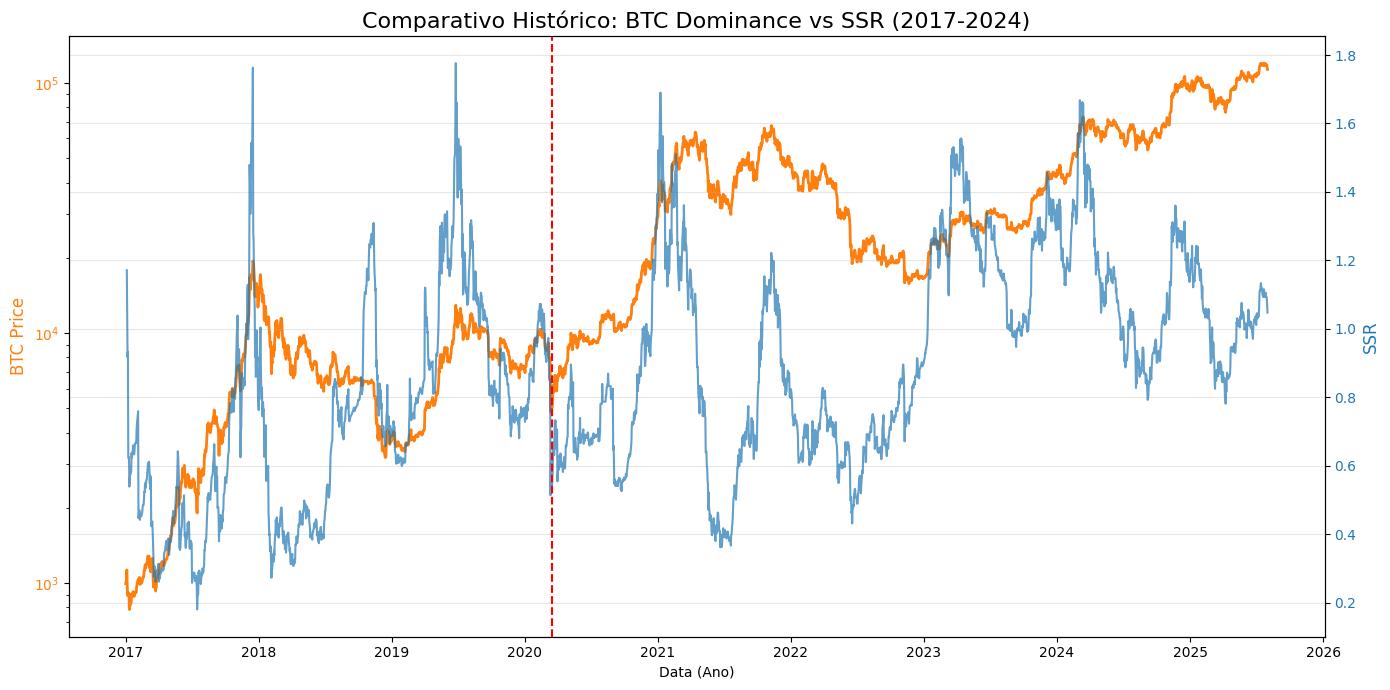

In [6]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('SSR', color=color, fontsize=12)
ax2.plot(df_ssr_diff['Data_UTC'], df_ssr_diff['ssr'], color=color, label='SSR', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs SSR (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## Flippening_Ratio (ETH_Cap/BTC_Cap)
- Diferença diária da razão ETH_Cap / BTC_Cap. Mede a velocidade com que o Ethereum ganha ou perde terreno frente ao Bitcoin, ajustado pela oferta (supply) de ambos.
- É o indicador definitivo de Rotação de Narrativa. O mercado cripto oscila entre "Ouro Digital" (BTC) e "Computador Mundial" (ETH).

- Fonte: https://br.tradingview.com/ (CRYPTOCAP:ETH/CRYPTOCAP:BTC)

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Rivalidade e Jogo de Soma Zero. A narrativa predominante era a da substituição tecnológica ("O Ethereum vai matar o Bitcoin"). Hipotetiza-se que picos na razão ETH/BTC geravam incerteza existencial sobre o Bitcoin, podendo causar correlação negativa momentânea ou volatilidade excessiva no preço do BTC, à medida que o capital especulativo migrava agressivamente tentando capturar o "Flippening".

## Hipótese 2: Era Institucional (Pós-2020)
Estabilização e Coexistência de Teses. O mercado amadureceu para entender o Bitcoin como "Ouro Digital" (Reserva de Valor) e o Ethereum como "Tech/Web3" (Plataforma). Hipotetiza-se que a razão ETH/BTC perdeu sua característica de ameaça e passou a funcionar como um indicador de Sentimento Risk-On.

ETH/BTC Sobe: O mercado está propenso ao risco. Geralmente, isso acompanha um cenário de alta para o preço do Bitcoin (embora o ETH suba mais rápido).

ETH/BTC Cai: O mercado está defensivo. O preço do Bitcoin tende a cair menos que o do Ethereum (outperformance relativa), mas a tendência geral do preço em dólares costuma ser de baixa ou lateralização.


### TRATAMENTO
- Primeira Diferença (Diff)
- Justificativa: A série é uma razão de preços/oferta que oscila em bandas. A diferença diária captura o momento exato da rotação de narrativas. Valores positivos indicam outperformance do ETH (pressão baixista na BTC.D).

In [9]:
df_flippening = (pd.read_csv(rf"raw/201809_Flippening_Ratio_Diff.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'flippening_close'}) 

                        [['Data_UTC', 'flippening_close']] 
 
)
df_flippening

df_flippening_diff =(
    df_periodo
        .merge(df_flippening, how='left', on='Data_UTC')
        .assign(flippening_close = lambda df: df['flippening_close'].ffill())
        .assign(flippening_close_diff = lambda df: df['flippening_close'].diff())
        .query("Data_UTC > '2020-01-01'")
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        [['Data_UTC','flippening_close','flippening_close_diff']]
)
df_flippening_diff
# print_dataframe_info(df_flippening_diff, "Flippening Diff") 

,Data_UTC,flippening_close,flippening_close_diff
1097,2020-01-02,0.109918,0.000675
1098,2020-01-03,0.110165,0.000247
1099,2020-01-04,0.109658,-0.000507
1100,2020-01-05,0.110773,0.001115
1101,2020-01-06,0.111761,0.000989
...,...,...,...
3131,2025-07-28,0.195125,-0.001599
3132,2025-07-29,0.195119,-0.000005
3133,2025-07-30,0.196119,0.000999
3134,2025-07-31,0.193782,-0.002337


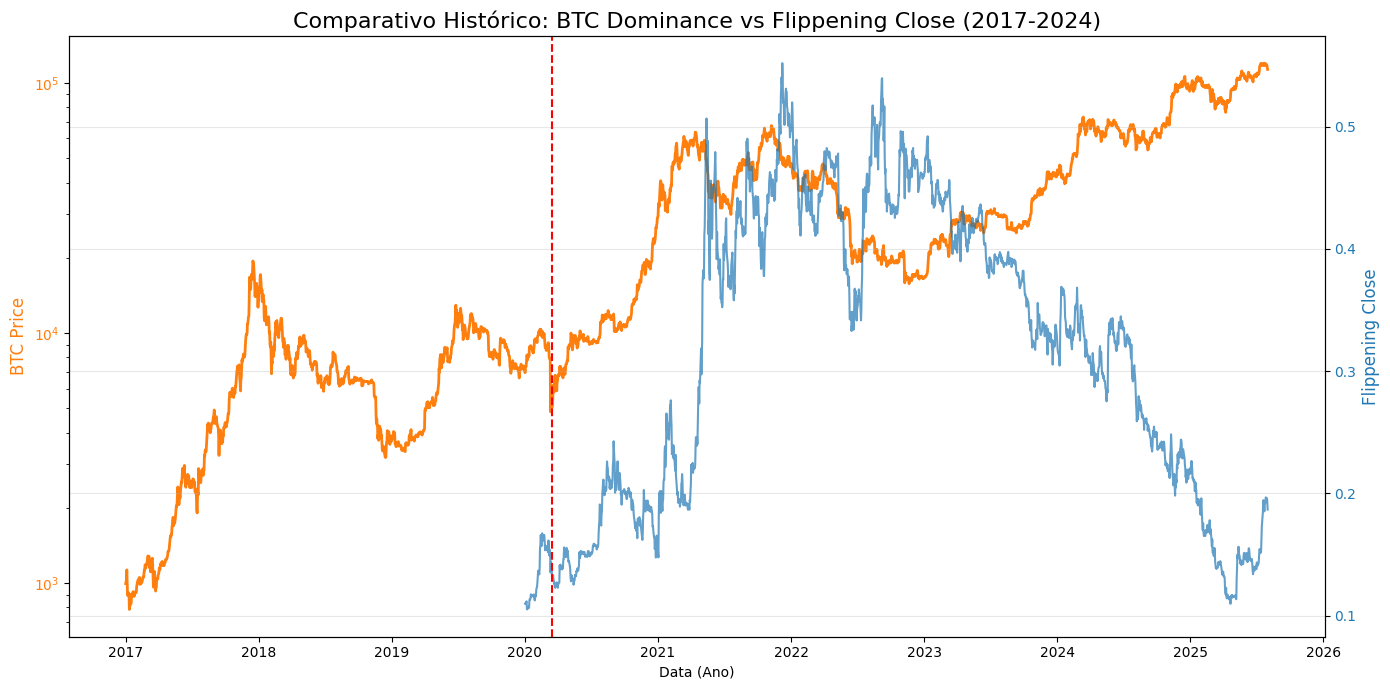

In [10]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('Flippening Close', color=color, fontsize=12)
ax2.plot(df_flippening_diff['Data_UTC'], df_flippening_diff['flippening_close'], color=color, label='Flippening Close', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs Flippening Close (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()